# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Data Loading

In [2]:
ratings = pd.read_csv("../data/raw/ratings.csv")
movies = pd.read_csv("../data/raw/movies.csv")
tags = pd.read_csv("../data/raw/tags.csv")

# Basic EDA

In [3]:
print(ratings.shape, movies.shape, tags.shape)

(100836, 4) (9742, 3) (3683, 4)


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
print(f"Unique users:  {ratings["userId"].nunique()}")
print(f"Unique movies: {movies["movieId"].nunique()}")
print(f"Rating range:  {ratings["rating"].min()} - {ratings["rating"].max()}")
print(f"Sparsity:      {1 - len(ratings) / (ratings["userId"].nunique() * ratings["movieId"].nunique()):.2%}")

Unique users:  610
Unique movies: 9742
Rating range:  0.5 - 5.0
Sparsity:      98.30%


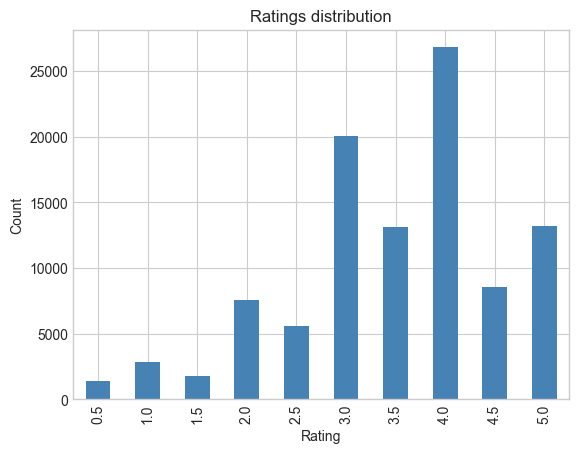

In [6]:
ratings["rating"].value_counts().sort_index().plot(kind = "bar", color ="steelblue")
plt.title("Ratings distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [7]:
ratings_per_user = ratings.groupby("userId").size()
print(ratings_per_user.describe())

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

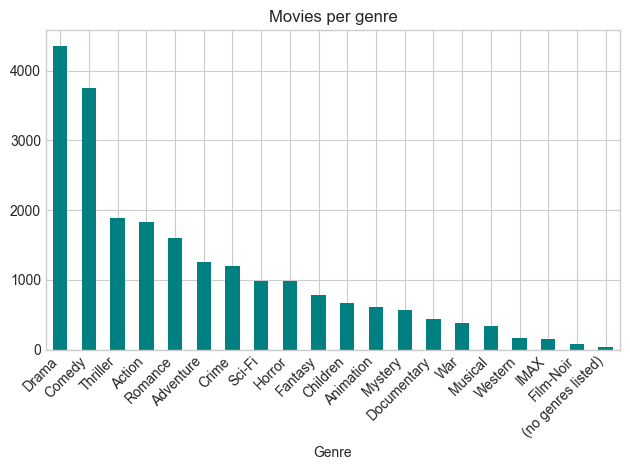

In [8]:
genre_df = (movies.assign(genre = movies["genres"].str.split("|")).explode("genre"))

genre_df["genre"].value_counts().plot(kind = "bar", color = "teal")
plt.title("Movies per genre")
plt.xlabel("Genre")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show

In [9]:
top_movies = (
    ratings.groupby("movieId")
    .agg(rating_count = ("rating", "count"), avg_rating = ("rating", "mean"))
    .merge(movies[["movieId", "title"]], on = "movieId")
    .sort_values("rating_count", ascending = False)
    .head(10)
)

print(top_movies[["title", "rating_count", "avg_rating"]].to_string(index=False))

                                    title  rating_count  avg_rating
                      Forrest Gump (1994)           329    4.164134
         Shawshank Redemption, The (1994)           317    4.429022
                      Pulp Fiction (1994)           307    4.197068
         Silence of the Lambs, The (1991)           279    4.161290
                       Matrix, The (1999)           278    4.192446
Star Wars: Episode IV - A New Hope (1977)           251    4.231076
                     Jurassic Park (1993)           238    3.750000
                        Braveheart (1995)           237    4.031646
        Terminator 2: Judgment Day (1991)           224    3.970982
                  Schindler's List (1993)           220    4.225000


In [10]:
df = ratings.merge(movies, on = "movieId")
df.to_csv("../data/processed/ratings_clean.csv", index = False)
print(f"Saved {len(df):,} rows")
df.head()

Saved 100,836 rows


,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
